<a href="https://colab.research.google.com/github/shubhamtrehan11-alt/Cumulative-Factor-Contributions-and-Portfolio-Returns/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

In [39]:
# =============================================================================
# CORE MODEL 2: ROLLING OLS REGRESSIONS
# Capture time-varying factor exposures.
# Window: 252 trading days (1 year), minimum 126 observations.
# =============================================================================

class RollingFactorModel:
    """
    Estimates time-varying factor loadings using a rolling window OLS.
    Essential for detecting factor exposure drift and regime changes.
    """

    def __init__(self, excess_returns: pd.DataFrame,
                 X_factors: pd.DataFrame,
                 window: int = 252,
                 min_obs: int = 126):
        self.excess_rets = excess_returns
        self.X           = X_factors
        self.window      = window
        self.min_obs     = min_obs

    def fit_ticker(self, ticker: str) -> pd.DataFrame:
        """
        Run rolling OLS for a single ticker.
        Returns DataFrame with rolling betas indexed by date.
        """
        y = self.excess_rets[ticker].dropna()
        X = sm.add_constant(self.X.reindex(y.index).dropna())
        y = y.reindex(X.index)

        rols = RollingOLS(y, X, window=self.window, min_nobs=self.min_obs)
        res  = rols.fit()

        betas = res.params.copy()
        betas.columns = ["Alpha"] + factor_cols_available
        return betas

    def fit_all(self) -> dict:
        """
        Fit rolling regressions for all tickers.
        Returns dict: {ticker → DataFrame of rolling betas}
        """
        log.info(f"Running rolling OLS (window={self.window}, min={self.min_obs}) …")
        rolling_betas = {}

        for i, ticker in enumerate(self.excess_rets.columns, 1):
            try:
                rolling_betas[ticker] = self.fit_ticker(ticker)
                if i % 5 == 0:
                    log.info(f"  Progress: {i}/{len(self.excess_rets.columns)}")
            except Exception as e:
                log.warning(f"  {ticker} rolling failed: {e}")

        log.info(f"✅ Rolling OLS complete for {len(rolling_betas)} tickers")
        return rolling_betas

    def get_cross_section(self, rolling_betas: dict,
                          date: pd.Timestamp = None,
                          factor: str = "Mkt-RF") -> pd.Series:
        """
        Extract cross-sectional factor loadings for a given date and factor.
        """
        if date is None:
            date = max(df.index.max() for df in rolling_betas.values())
        return pd.Series({
            t: betas.loc[:date, factor].iloc[-1]
            for t, betas in rolling_betas.items()
            if factor in betas.columns and len(betas.loc[:date]) > 0
        })


# ── Fit Rolling Models ────────────────────────────────────────────────────────
rolling_model  = RollingFactorModel(
    excess_returns, X_factors,
    window=CONFIG["rolling_window"],
    min_obs=CONFIG["min_obs"]
)
rolling_betas  = rolling_model.fit_all()

# Extract latest rolling betas for all stocks
latest_date    = max(df.index.max() for df in rolling_betas.values())
latest_betas   = {}
for ticker, betas in rolling_betas.items():
    last_row = betas.dropna(how="all").iloc[-1] if len(betas.dropna(how="all")) > 0 else None
    if last_row is not None:
        latest_betas[ticker] = last_row

latest_betas_df = pd.DataFrame(latest_betas).T
print(f"\n📊 LATEST ROLLING BETAS (as of {latest_date.date()})")
print("="*80)
factor_display = [c for c in ["Alpha", "Mkt-RF", "SMB", "HML", "RMW", "CMA", "WML"] if c in latest_betas_df.columns]
print(latest_betas_df[factor_display].round(4).to_string())


📊 LATEST ROLLING BETAS (as of 2026-04-30)
        Alpha  Mkt-RF     SMB     HML     RMW     CMA     WML
AAPL   0.0000  1.2192 -0.1454 -0.1122  0.5367  0.3841 -0.0646
ABBV   0.0000  0.3696 -0.0125 -0.2705 -0.0696  0.8587 -0.0514
AMZN   0.0002  1.5448 -0.2791  0.0245  0.2961 -0.8279 -0.3122
BAC   -0.0005  1.2284 -0.1785  1.0061 -0.1439 -0.1501 -0.0035
COP    0.0008  0.4469 -0.2054  1.2785 -0.1695 -0.6719 -0.5733
COST  -0.0003  0.2079  0.1025 -0.0567  0.2301  0.4288  0.1380
CVX    0.0012  0.1527 -0.0812  0.6289 -0.0945 -0.1657 -0.3235
EOG    0.0006  0.2051 -0.2107  0.9946 -0.2326 -0.4318 -0.4189
GOOGL  0.0024  1.1028  0.1263 -0.3262  0.4695 -0.4688  0.1618
GS     0.0001  1.4169  0.1290  0.4875 -0.2278  0.1940  0.2832
HD    -0.0011  0.9800  0.5569 -0.2256  0.6965  0.9432 -0.0460
JNJ    0.0012  0.1120  0.0296 -0.0623  0.0722  0.5701  0.0840
JPM   -0.0005  1.1822 -0.2545  0.6869 -0.1420  0.0600  0.0756
LOW   -0.0006  1.0160  0.7886 -0.3058  0.8404  1.0521  0.0190
MRK    0.0004  0.5206  0.41

### 1. Rolling OLS Regressions (`RollingFactorModel`)

This class is responsible for calculating time-varying factor exposures (betas) for each stock using a rolling Ordinary Least Squares (OLS) regression. It helps understand how a stock's sensitivity to various factors changes over time.


In [42]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import logging

log = logging.getLogger(__name__)

# Assuming factor_cols_available is defined elsewhere, e.g., in CONFIG
# For demonstration, let's define it here if it's not directly accessible
# factor_cols_available = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'WML']

class RollingFactorModel:
    """
    Estimates time-varying factor loadings using a rolling window OLS.
    Essential for detecting factor exposure drift and regime changes.
    """

    def __init__(self, excess_returns: pd.DataFrame,
                 X_factors: pd.DataFrame,
                 window: int = 252,
                 min_obs: int = 126):
        self.excess_rets = excess_returns
        self.X           = X_factors
        self.window      = window
        self.min_obs     = min_obs

    def fit_ticker(self, ticker: str) -> pd.DataFrame:
        """
        Run rolling OLS for a single ticker.
        Returns DataFrame with rolling betas indexed by date.
        """
        y = self.excess_rets[ticker].dropna()
        X = sm.add_constant(self.X.reindex(y.index).dropna())
        y = y.reindex(X.index)

        rols = RollingOLS(y, X, window=self.window, min_nobs=self.min_obs)
        res  = rols.fit()

        betas = res.params.copy()
        betas.columns = ["Alpha"] + factor_cols_available
        return betas

    def fit_all(self) -> dict:
        """
        Fit rolling regressions for all tickers.
        Returns dict: {ticker → DataFrame of rolling betas}
        """
        log.info(f"Running rolling OLS (window={self.window}, min={self.min_obs}) …")
        rolling_betas = {}

        for i, ticker in enumerate(self.excess_rets.columns, 1):
            try:
                rolling_betas[ticker] = self.fit_ticker(ticker)
                if i % 5 == 0:
                    log.info(f"  Progress: {i}/{len(self.excess_rets.columns)}")
            except Exception as e:
                log.warning(f"  {ticker} rolling failed: {e}")

        log.info(f"✅ Rolling OLS complete for {len(rolling_betas)} tickers")
        return rolling_betas

    def get_cross_section(self, rolling_betas: dict,
                          date: pd.Timestamp = None,
                          factor: str = "Mkt-RF") -> pd.Series:
        """
        Extract cross-sectional factor loadings for a given date and factor.
        """
        if date is None:
            date = max(df.index.max() for df in rolling_betas.values())
        return pd.Series({
            t: betas.loc[:date, factor].iloc[-1]
            for t, betas in rolling_betas.items()
            if factor in betas.columns and len(betas.loc[:date]) > 0
        })

#### **Conceptual Flowchart for `RollingFactorModel`**

```mermaid
graph TD
    A[Start]
    B{Initialize RollingFactorModel}
    C[Inputs: Excess Stock Returns, Factor Returns, Window Size, Min Observations]
    D{For Each Stock Ticker}
    E[Prepare Data: Align Stock and Factor Returns, Add Constant]
    F[Run Rolling OLS Regression]
    G[Extract Rolling Betas (Alpha + Factor Loadings)]
    H[Store Betas for Ticker]
    I{All Tickers Processed?}
    J[Consolidate Latest Betas]
    K[Output: Dictionary of Rolling Betas, Latest Betas DataFrame]

    A --> B
    B --> C
    C --> D
    D --> E
    E --> F
    F --> G
    G --> H
    H --> I
    I -- Yes --> J
    I -- No --> D
    J --> K
```

This diagram illustrates how the `RollingFactorModel` takes in stock and factor returns, performs a rolling regression for each stock, and ultimately provides a dataframe of the latest factor exposures (betas).

### 2. Return Attribution (`ReturnAttributor`)

This class is designed to break down a portfolio's returns into contributions from systematic factors (like market, size, value, etc.) and an idiosyncratic 'alpha' component. It's crucial for understanding the sources of portfolio performance.


In [43]:
import pandas as pd

class ReturnAttributor:
    """
    Decomposes portfolio and individual stock returns into:
      - Factor contributions (systematic)
      - Alpha (idiosyncratic / skill)

    Method: Brinson-Hood-Beebower adapted for factor models.
    """

    def __init__(self, port_model_result, X_factors: pd.DataFrame,
                 portfolio_returns: pd.Series):
        self.model   = port_model_result
        self.X       = X_factors
        self.port_rt = portfolio_returns

    def factor_contributions(self) -> pd.DataFrame:
        """
        Compute daily factor contribution to portfolio return.
        Contribution_k(t) = β_k × Factor_Return_k(t)
        """
        betas = self.model.params.drop("const", errors="ignore")
        X_aligned = self.X[betas.index].reindex(self.port_rt.index).dropna()
        port_aligned = self.port_rt.reindex(X_aligned.index)

        # Daily contributions per factor
        contributions = X_aligned.multiply(betas, axis=1)
        contributions["Alpha"] = self.model.params.get("const", 0)
        contributions["Residual"] = (
            port_aligned - contributions.drop("Alpha", axis=1).sum(axis=1)
            - self.model.params.get("const", 0)
        )
        contributions["Portfolio"] = port_aligned
        return contributions

    def cumulative_attribution(self, contributions: pd.DataFrame) -> pd.DataFrame:
        """
        Compound daily contributions into cumulative return paths.
        Uses (1 + r).cumprod() - 1 for geometric compounding.
        """
        factor_cols = [c for c in contributions.columns
                       if c not in ["Portfolio", "Residual"]]
        cum = (1 + contributions[factor_cols]).cumprod() - 1
        cum["Portfolio"] = (1 + contributions["Portfolio"]).cumprod() - 1
        return cum

    def period_summary(self, contributions: pd.DataFrame,
                       freq: str = "M") -> pd.DataFrame:
        """
        Aggregate daily contributions to monthly/quarterly periods.
        """
        factor_cols = [c for c in contributions.columns if c != "Portfolio"]
        monthly = contributions[factor_cols].resample(freq).sum()
        monthly["Portfolio"] = contributions["Portfolio"].resample(freq).sum()
        return monthly

    def run(self):
        contrib    = self.factor_contributions()
        cum_attr   = self.cumulative_attribution(contrib)
        monthly    = self.period_summary(contrib, freq="ME")
        return contrib, cum_attr, monthly

#### **Conceptual Flowchart for `ReturnAttributor`**

```mermaid
graph TD
    A[Start]
    B{Initialize ReturnAttributor}
    C[Inputs: Portfolio Model Result (Betas), Factor Returns, Portfolio Returns]
    D{Calculate Daily Factor Contributions}
    E[Contribution = Beta × Factor_Return]
    F[Include Alpha and Residual]
    G{Calculate Cumulative Attribution}
    H[Compound Daily Contributions]
    I{Generate Period Summary}
    J[Aggregate Daily Contributions to Monthly/Quarterly]
    K[Output: Daily Contributions, Cumulative Contributions, Period Summaries]

    A --> B
    B --> C
    C --> D
    D --> E
    E --> F
    F --> G
    G --> H
    H --> I
    I --> J
    J --> K
```

This diagram shows the process of the `ReturnAttributor` in breaking down portfolio returns into the contributions from various factors and an alpha component, and then aggregating these contributions over different time periods.

### Cumulative Factor Contributions to Portfolio Return

This chart visualizes the cumulative performance of each factor (`Mkt-RF`, `SMB`, `HML`, `RMW`, `CMA`, `WML`, `Alpha`) and the `Portfolio` itself over the investment period. It helps in understanding which factors have been driving the overall portfolio returns cumulatively.

### Download Cumulative Factor Contributions and Portfolio Return

Run the following cell to download the `cum_attribution` DataFrame as a CSV file.

In [67]:
from google.colab import files

# Save the DataFrame to a CSV file
cum_attribution.to_csv('cumulative_attribution.csv', index=True)

# Download the CSV file
files.download('cumulative_attribution.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
import plotly.express as px

# Select the relevant columns from cum_attribution for plotting
# Exclude 'Residual' as it's typically very close to zero cumulatively
plot_data = cum_attribution.drop(columns=['Residual'], errors='ignore')

# Create the interactive line plot using Plotly Express
fig = px.line(
    plot_data,
    x=plot_data.index,
    y=plot_data.columns,
    title='Cumulative Factor Contributions and Portfolio Return',
    labels={
        'index': 'Date',
        'value': 'Cumulative Return',
        'variable': 'Factors'
    },
    height=600
)

# Update layout for better readability
fig.update_layout(
    hovermode='x unified',
    title_x=0.5, # Center the title
    legend_title_text='Factors',
    font=dict(size=12),
    xaxis_title='Date',
    yaxis_title='Cumulative Return'
)

fig.show()

### Latest Rolling Betas Heatmap

This heatmap visually represents the `LATEST ROLLING BETAS` for all the stocks in your portfolio. Each row corresponds to a stock, and each column represents a factor (Alpha, Mkt-RF, SMB, HML, RMW, CMA, WML). The color intensity indicates the magnitude of the factor loading (beta), allowing you to quickly identify which stocks have strong or weak exposures to different factors.

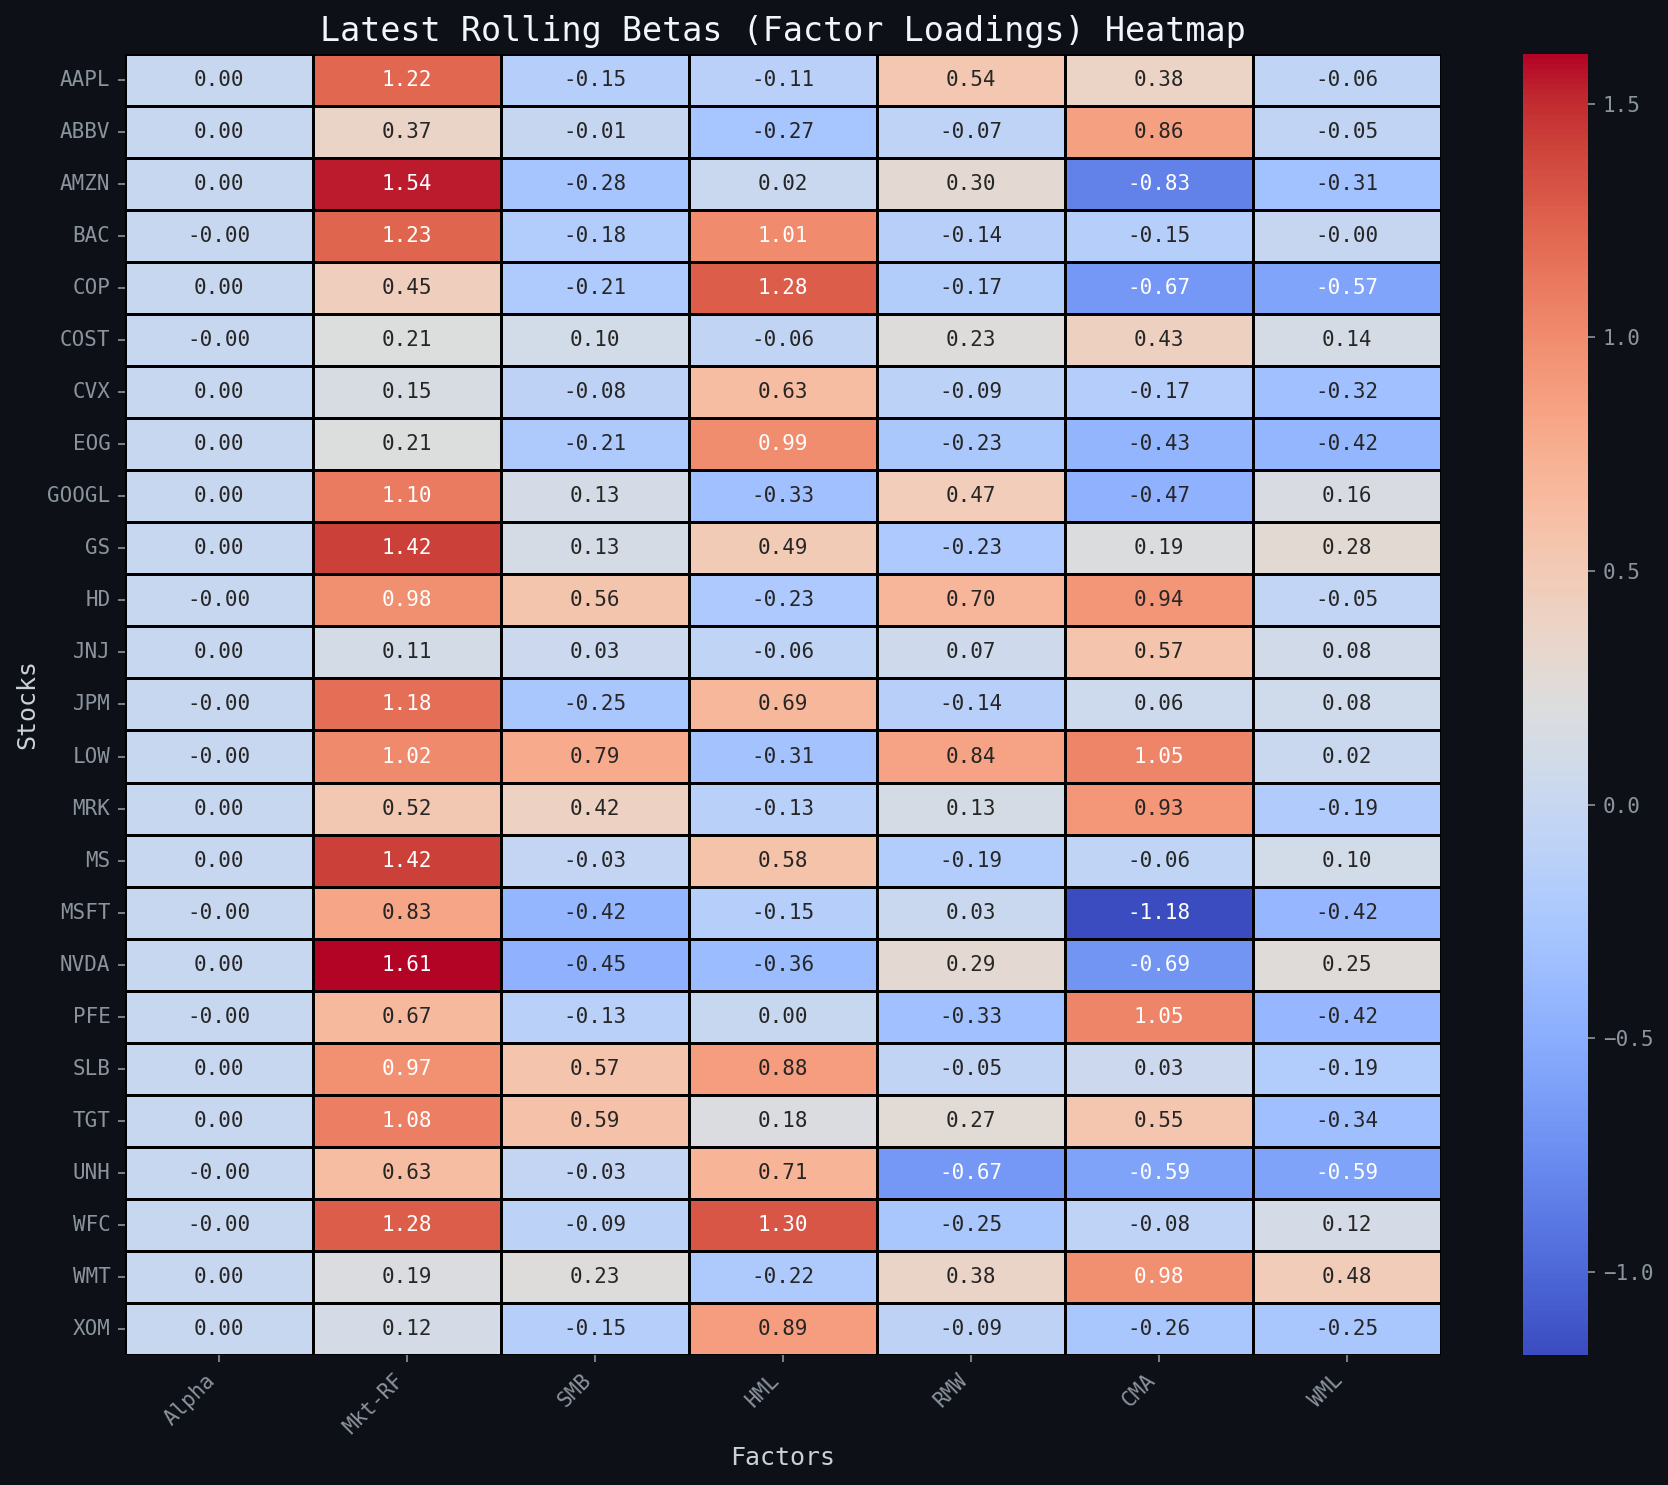

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the DataFrame contains only the factor columns for display
factors_to_plot = [c for c in ["Alpha", "Mkt-RF", "SMB", "HML", "RMW", "CMA", "WML"] if c in latest_betas_df.columns]
plot_df = latest_betas_df[factors_to_plot]

# Create the heatmap
fig = plt.figure(figsize=(12, 10))
sns.heatmap(plot_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Latest Rolling Betas (Factor Loadings) Heatmap', fontsize=16)
plt.xlabel('Factors', fontsize=12)
plt.ylabel('Stocks', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [41]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'ModelOutput'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary", "ModelOutput"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig)

In [35]:
print('\n📊 TOP 5 CONTRIBUTING FACTORS')
print('='*80)
top_5_contributing_factors = ann_contrib.drop('Residual', errors='ignore').nlargest(5)
display(top_5_contributing_factors)


📊 TOP 5 CONTRIBUTING FACTORS


,0
Mkt-RF,0.1080
Alpha,0.0278
SMB,0.0013
RMW,-0.0006
CMA,-0.0006


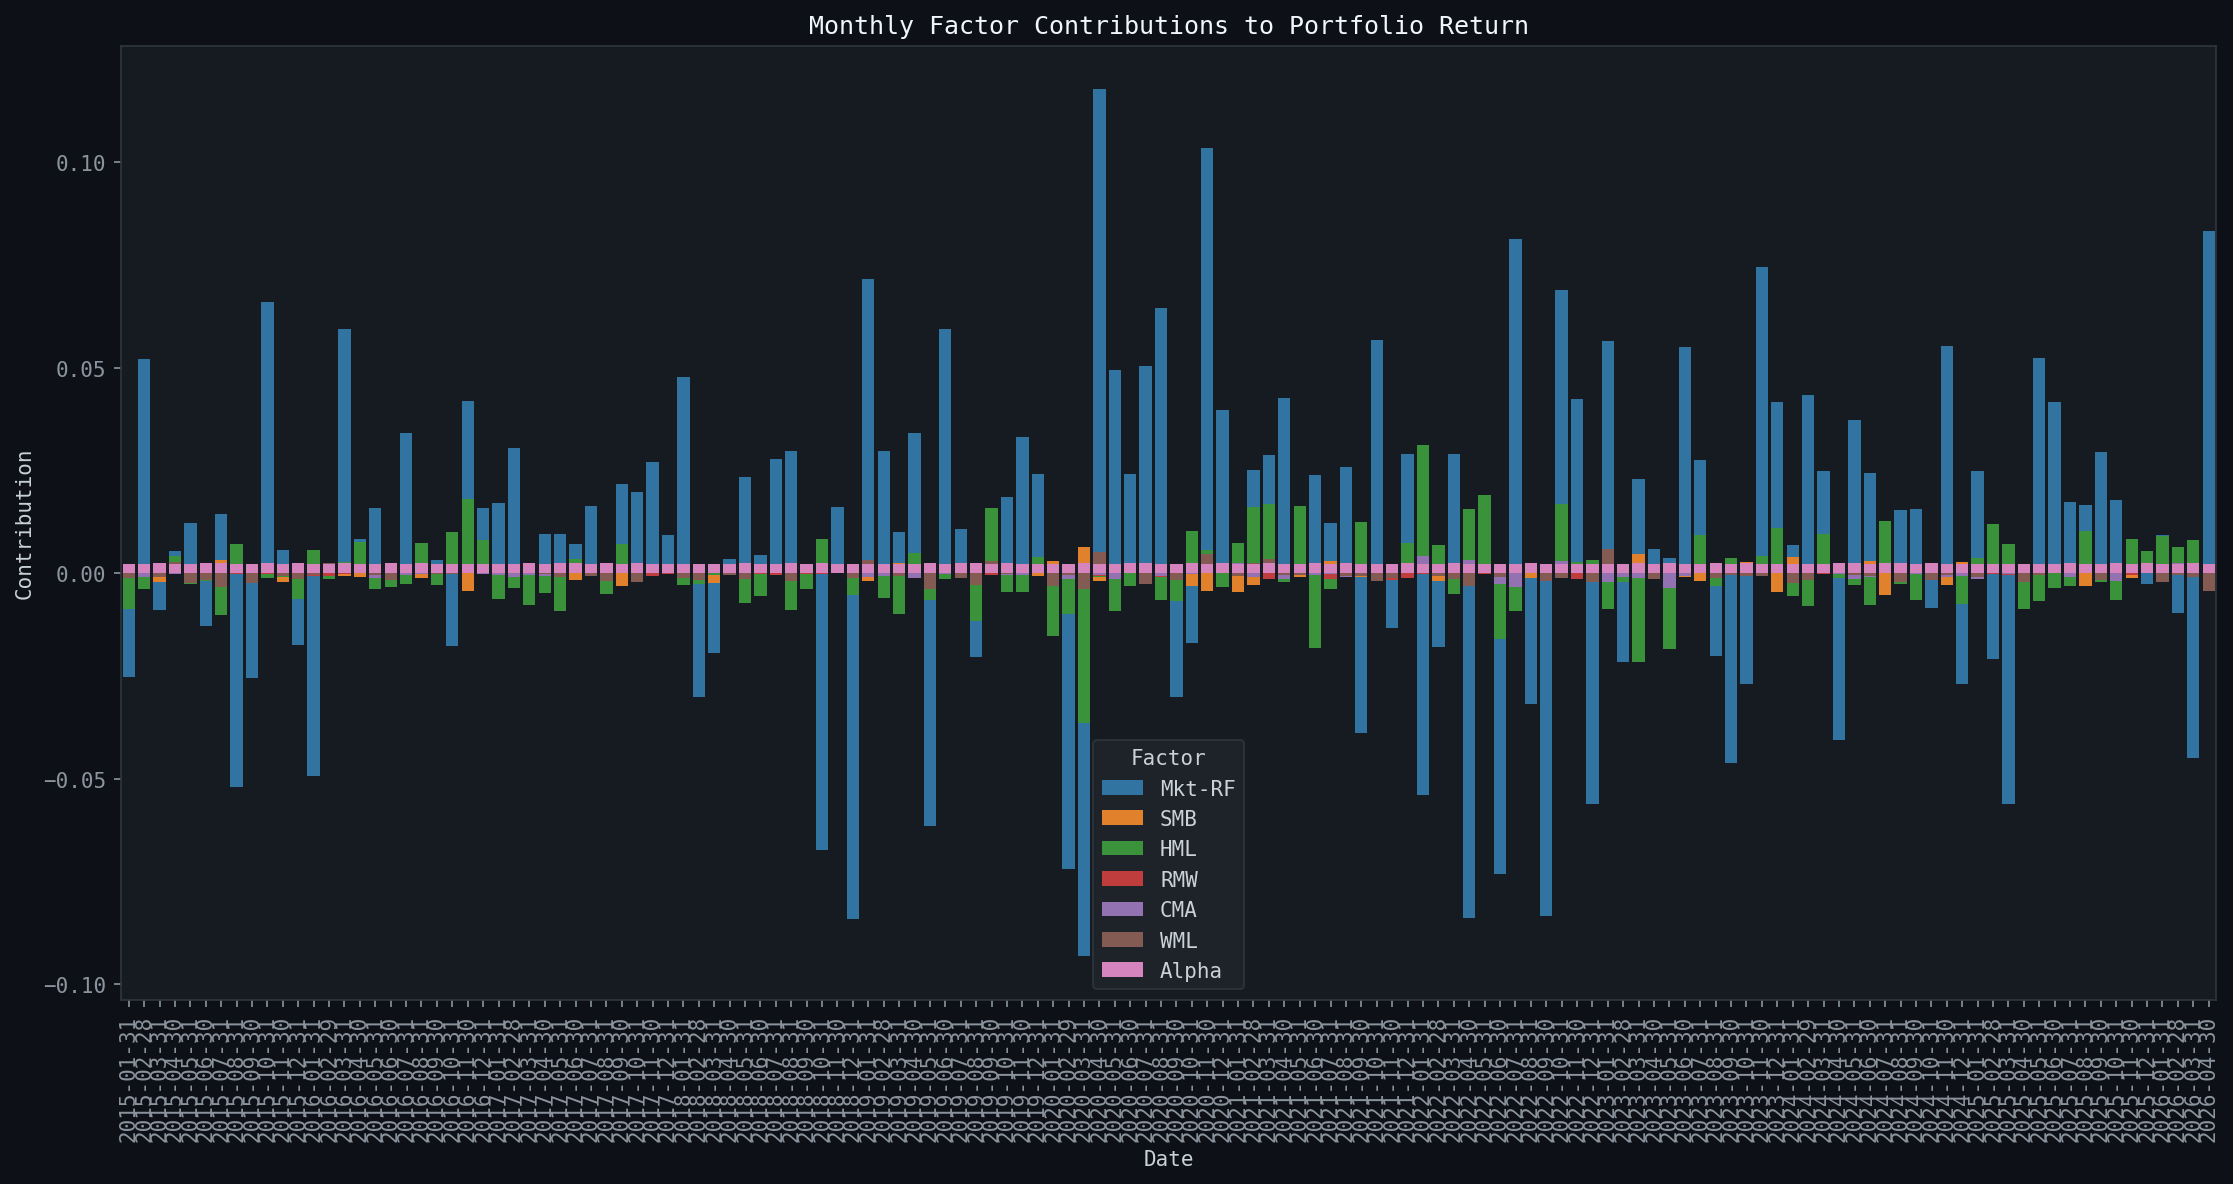

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data for plotting
monthly_plot_df = monthly_attr.drop(columns=['Residual', 'Portfolio']).stack().reset_index()
monthly_plot_df.columns = ['Date', 'Factor', 'Contribution']

# Set up the plot
plt.figure(figsize=(15, 8))
sns.barplot(data=monthly_plot_df, x='Date', y='Contribution', hue='Factor', dodge=False)

plt.title('Monthly Factor Contributions to Portfolio Return')
plt.xlabel('Date')
plt.ylabel('Contribution')
plt.xticks(rotation=90)
plt.legend(title='Factor')
plt.tight_layout()
plt.show()

This bar chart visualizes the monthly contributions of each factor to the portfolio's return over time. Each bar represents a month, and the stacked segments within the bar show the individual contribution of each factor (Mkt-RF, SMB, HML, RMW, CMA, WML, Alpha) for that month.

In [37]:
# =============================================================================
# CORE MODEL 3: RETURN ATTRIBUTION
# Decompose portfolio returns into factor contributions + alpha.
# Attribution = loading × factor_return for each period.
# =============================================================================

class ReturnAttributor:
    """
    Decomposes portfolio and individual stock returns into:
      - Factor contributions (systematic)
      - Alpha (idiosyncratic / skill)

    Method: Brinson-Hood-Beebower adapted for factor models.
    """

    def __init__(self, port_model_result, X_factors: pd.DataFrame,
                 portfolio_returns: pd.Series):
        self.model   = port_model_result
        self.X       = X_factors
        self.port_rt = portfolio_returns

    def factor_contributions(self) -> pd.DataFrame:
        """
        Compute daily factor contribution to portfolio return.
        Contribution_k(t) = β_k × Factor_Return_k(t)
        """
        betas = self.model.params.drop("const", errors="ignore")
        X_aligned = self.X[betas.index].reindex(self.port_rt.index).dropna()
        port_aligned = self.port_rt.reindex(X_aligned.index)

        # Daily contributions per factor
        contributions = X_aligned.multiply(betas, axis=1)
        contributions["Alpha"] = self.model.params.get("const", 0)
        contributions["Residual"] = (
            port_aligned - contributions.drop("Alpha", axis=1).sum(axis=1)
            - self.model.params.get("const", 0)
        )
        contributions["Portfolio"] = port_aligned
        return contributions

    def cumulative_attribution(self, contributions: pd.DataFrame) -> pd.DataFrame:
        """
        Compound daily contributions into cumulative return paths.
        Uses (1 + r).cumprod() - 1 for geometric compounding.
        """
        factor_cols = [c for c in contributions.columns
                       if c not in ["Portfolio", "Residual"]]
        cum = (1 + contributions[factor_cols]).cumprod() - 1
        cum["Portfolio"] = (1 + contributions["Portfolio"]).cumprod() - 1
        return cum

    def period_summary(self, contributions: pd.DataFrame,
                       freq: str = "M") -> pd.DataFrame:
        """
        Aggregate daily contributions to monthly/quarterly periods.
        """
        factor_cols = [c for c in contributions.columns if c != "Portfolio"]
        monthly = contributions[factor_cols].resample(freq).sum()
        monthly["Portfolio"] = contributions["Portfolio"].resample(freq).sum()
        return monthly

    def run(self):
        contrib    = self.factor_contributions()
        cum_attr   = self.cumulative_attribution(contrib)
        monthly    = self.period_summary(contrib, freq="ME")
        return contrib, cum_attr, monthly

In [38]:
from IPython.display import display

# ── Run Attribution ───────────────────────────────────────────────────────────
attributor = ReturnAttributor(port_model, X_factors, portfolio_returns)
contributions, cum_attribution, monthly_attr = attributor.run()

# Annual summary
ann_contrib = contributions.drop("Portfolio", axis=1).mean() * 252
ann_total   = portfolio_returns.mean() * 252

print("\n📊 ANNUALISED RETURN ATTRIBUTION")
print("="*55)
for name, val in ann_contrib.items():
    pct = val / ann_total * 100 if ann_total != 0 else 0
    bar = "█" * int(abs(pct) / 3)
    sign = "+" if val >= 0 else ""
    print(f"  {name:<12} {sign}{val*100:>6.2f}%  ({sign}{pct:>5.1f}%)  {bar}")
print(f"  {'Total':<12} {ann_total*100:>+6.2f}%  (100.0%)")

print("\nDisplaying first 5 rows of Monthly Attribution:")
display(monthly_attr.head())


📊 ANNUALISED RETURN ATTRIBUTION
  Mkt-RF       + 10.80%  (+ 81.8%)  ███████████████████████████
  SMB          +  0.13%  (+  1.0%)  
  HML           -0.19%  ( -1.5%)  
  RMW           -0.06%  ( -0.5%)  
  CMA           -0.06%  ( -0.5%)  
  WML           -0.19%  ( -1.4%)  
  Alpha        +  2.78%  (+ 21.1%)  ███████
  Residual      -0.00%  ( -0.0%)  
  Total        +13.21%  (100.0%)

Displaying first 5 rows of Monthly Attribution:


,Mkt-RF,SMB,HML,RMW,CMA,WML,Alpha,Residual,Portfolio
Date,,,,,,,,,
2015-01-31,-0.0252,0.0002,-0.0088,-0.0005,-0.0010,-0.0011,0.0021,-0.0033,-0.0375
2015-02-28,0.0522,-0.0002,-0.0040,0.0003,-0.0008,0.0013,0.0021,0.0069,0.0577
2015-03-31,-0.0090,-0.0021,-0.0009,-0.0000,-0.0003,-0.0010,0.0024,0.0003,-0.0106
2015-04-30,0.0054,0.0020,0.0043,-0.0000,-0.0003,0.0026,0.0023,0.0075,0.0238
2015-05-31,0.0121,-0.0006,-0.0026,0.0004,-0.0004,-0.0023,0.0022,-0.0044,0.0044
